## NEP_ALTBC

### Example

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import time
from altbc_analyzer.altbc_analyzer import ALTBC_Analyzer
from ase.io import read
from ase.io.vasp import read_vasp_xdatcar
from matplotlib.colors import PowerNorm
from scipy.stats import gaussian_kde

def analyze_file(filename, filetype='POSCAR', cutoff=4.0, theta_min=155, theta_max=180, frame_interval=10):
    """
    Analyze input file type
    """
    analyzer = ALTBC_Analyzer(cutoff, theta_min, theta_max)
    
    if filetype == 'POSCAR':
        atoms = read(filename)
        return analyzer.compute_altbc(atoms)
    if filetype == 'XYZ':
        structures = read(filename, index=slice(0, None, frame_interval))
        data_frames = [analyzer.compute_altbc(structure) for structure in structures]
        return pd.concat(data_frames, ignore_index=True) if data_frames else pd.DataFrame()
    elif filetype == 'XDATCAR':
        structures = read_vasp_xdatcar(filename, index=slice(0, None, frame_interval))
        if len(structures[0]) > 1000:
            print("Please use POSCAR file type for analysis if the number of atoms exceeds 1000!")
            sys.exit(1)
        data_frames = [analyzer.compute_altbc(structure) for structure in structures]
        return pd.concat(data_frames, ignore_index=True) if data_frames else pd.DataFrame()
    else:
        print("Unrecognized file type!")
        return pd.DataFrame()

def plot_common_settings():
    plt.xlabel("Distance r1 (Å)")
    plt.ylabel("Distance r2 (Å)")
    plt.xlim(2.5, 3.8)
    plt.ylim(2.5, 3.8)
    plt.xticks(np.arange(2.6, 3.9, 0.2))
    plt.yticks(np.arange(2.6, 3.9, 0.2))
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

def plot_results(df, plot_type='scatter', plot_bar=True):
    if df.empty:
        print("No data available for plotting.")
        return
    
    x, y, z = np.array(df["AB"]), np.array(df["BC"]), np.array(df["pair"])
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)    
    z_kde = kde(xy) * z * z  # Calculate z_kde here to use in both plots
    # print(np.max(z_kde), np.min(z_kde))

    if plot_type == 'scatter':
        plot_scatter(x, y, z_kde, plot_bar)
    elif plot_type == 'kde':
        plot_kde(kde, x, y, z_kde, plot_bar)

def plot_scatter(x, y, z_kde, plot_bar=True, vmin=0, vmax=0.15, gamma=1.5, if_norm=True):
    cmap = plt.get_cmap('viridis')
    if if_norm == True:
        norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax) # 使用 PowerNorm 赋予颜色变化非线性, gamma < 1时低频变化更剧烈
        scatter = plt.scatter(x, y, c=z_kde, cmap=cmap, s=1, alpha=1, norm=norm)
    else:
        scatter = plt.scatter(x, y, c=z_kde, cmap=cmap, s=1, alpha=1)
    if plot_bar:
        cbar = plt.colorbar(scatter, label='P(r1,r2)')
        if vmin is not None and vmax is not None:
            scatter.set_clim(vmin, vmax)
        cbar.set_ticks([])
    plot_common_settings()

def plot_kde(kde, x, y, z_kde, plot_bar=True):
    x1, y1 = np.arange(2.5, 3.8, 0.01), np.arange(2.5, 3.8, 0.01)
    X, Y = np.meshgrid(x1, y1)
    kde_values = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    
    # Normalize kde_values to match the range of z_kde
    kde_values = kde_values * (z_kde.max() / kde_values.max())
    
    plt.figure(figsize=(6, 5))
    plt.imshow(kde_values, extent=[2.5, 3.8, 2.5, 3.8], origin='lower', cmap='viridis', aspect='auto')
    if plot_bar:
        cbar = plt.colorbar(label='P(r1,r2)')
        cbar.set_ticks([])
    plot_common_settings()

Time used: 4.024 s


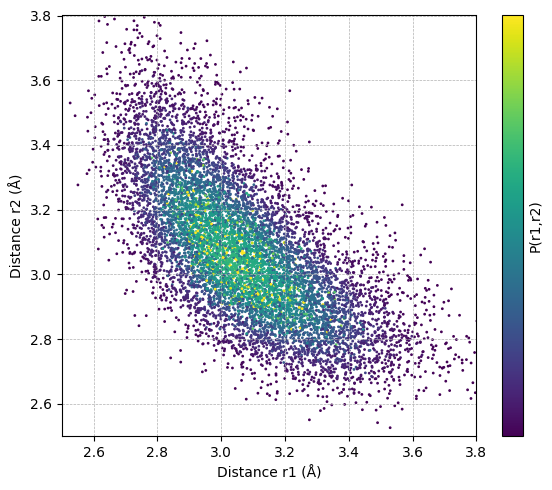

In [5]:
start_time = time.time()
# df = analyze_file('./XDATCAR', filetype='XDATCAR', frame_interval=10)
df = analyze_file('../NEP_Order_parameter/split_movie_files/split_500.xyz', filetype='XYZ', frame_interval=180)
plt.figure(figsize=(6, 5))
plot_results(df, plot_type='scatter')  # 'scatter' or 'kde'
plt.tight_layout()
plt.savefig('./altbc_550K.png', bbox_inches='tight')
end_time = time.time()
print("Time used: {:.3f} s".format(end_time - start_time))

In [2]:
start_time = time.time()
# df = analyze_file('./XDATCAR', filetype='XDATCAR', frame_interval=10)
df = analyze_file('../NEP_Order_parameter/split_dump_files/split_1200.xyz', filetype='XYZ', frame_interval=1)
plt.figure(figsize=(6, 5))
plot_results(df, plot_type='scatter')  # 'scatter' or 'kde'
plt.tight_layout()
plt.savefig('./altbc_1000K.png', bbox_inches='tight')
end_time = time.time()
print("Time used: {:.3f} s".format(end_time - start_time))

No data available for plotting.
Time used: 9.397 s


<Figure size 600x500 with 0 Axes>

### GeTe

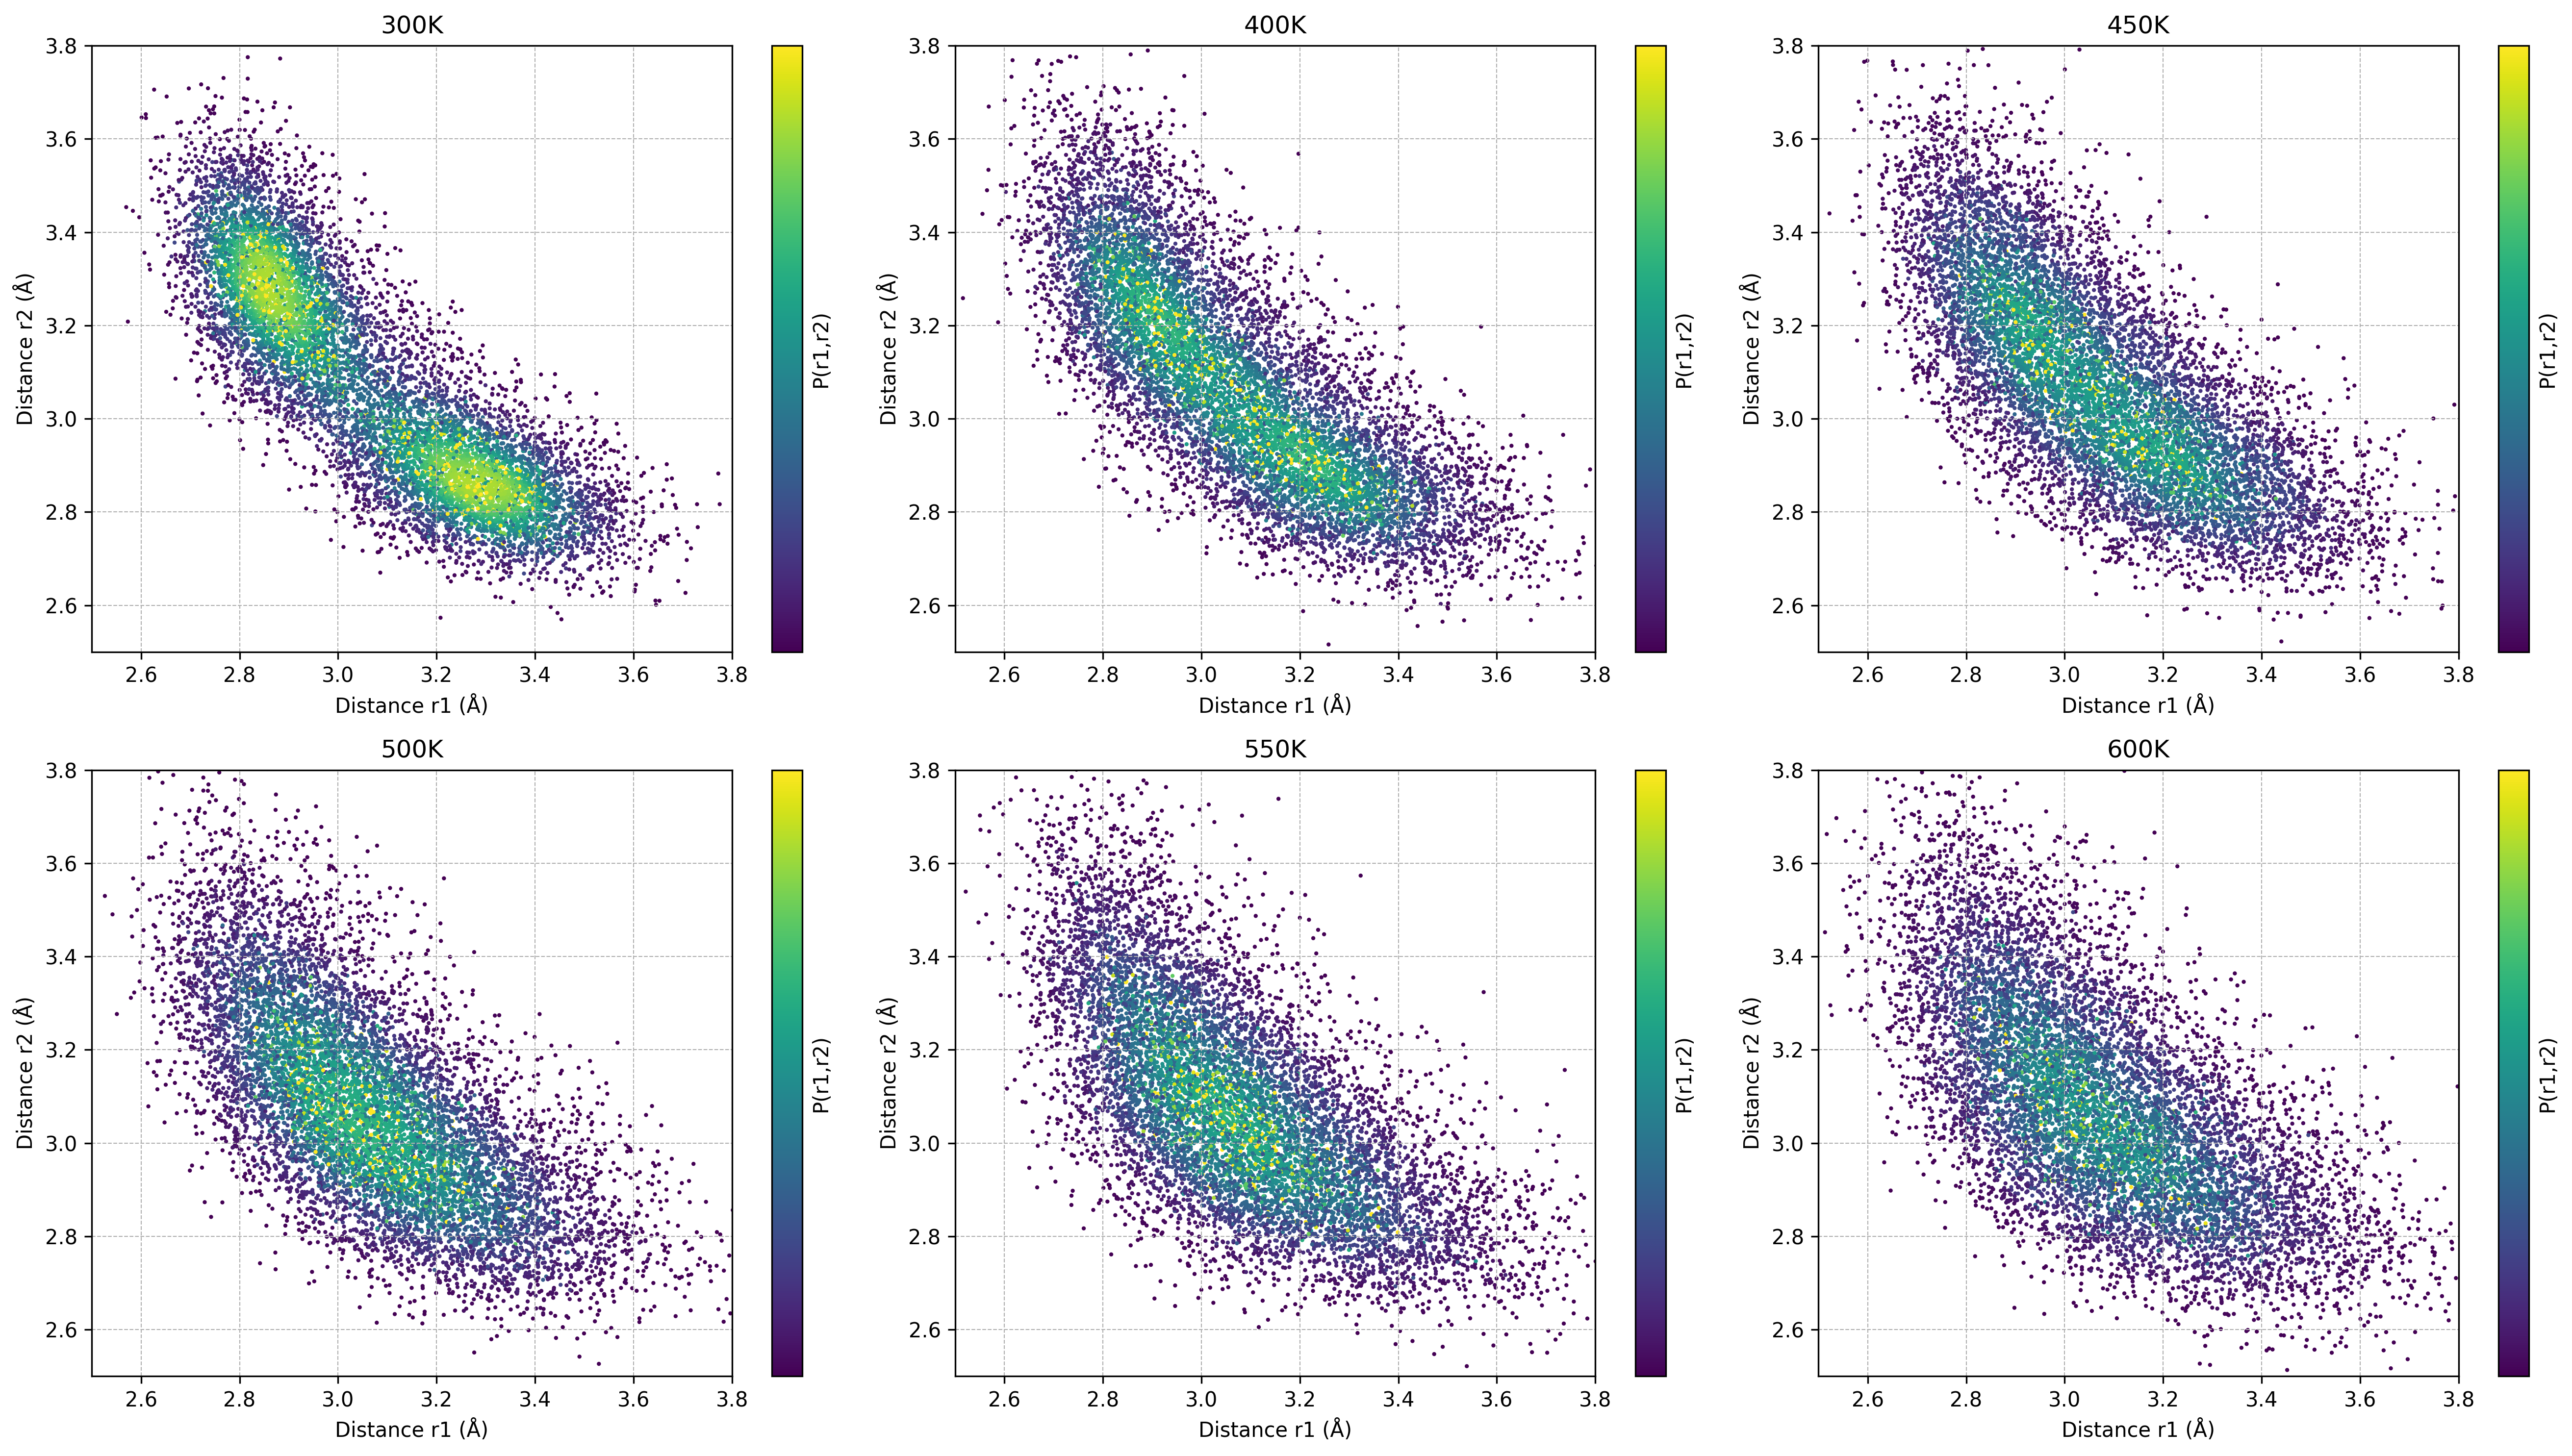

In [6]:
plt.figure(figsize=(18, 10), dpi=300)

plt.subplot(231)
df = analyze_file('../NEP_Order_parameter/split_xyz_files/split_300.xyz', filetype='XYZ', frame_interval=180)
plot_results(df, plot_type='scatter')
plt.title("300K")

plt.subplot(232)
df = analyze_file('../NEP_Order_parameter/split_xyz_files/split_400.xyz', filetype='XYZ', frame_interval=180)
plot_results(df, plot_type='scatter')
plt.title("400K")

plt.subplot(233)
df = analyze_file('../NEP_Order_parameter/split_xyz_files/split_450.xyz', filetype='XYZ', frame_interval=180)
plot_results(df, plot_type='scatter')
plt.title("450K")

plt.subplot(234)
df = analyze_file('../NEP_Order_parameter/split_xyz_files/split_500.xyz', filetype='XYZ', frame_interval=180)
plot_results(df, plot_type='scatter')
plt.title("500K")

plt.subplot(235)
df = analyze_file('../NEP_Order_parameter/split_xyz_files/split_550.xyz', filetype='XYZ', frame_interval=180)
plot_results(df, plot_type='scatter')
plt.title("550K")

plt.subplot(236)
df = analyze_file('../NEP_Order_parameter/split_xyz_files/split_600.xyz', filetype='XYZ', frame_interval=180)
plot_results(df, plot_type='scatter')
plt.title("600K")

plt.tight_layout()
plt.savefig('./altbc.png', bbox_inches='tight')